In [1]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Set pandas display options for better readability of DataFrames
pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.max_columns', None)

## 📊 Loading Customer, Loan, and Bureau Datasets
Three datasets were loaded, each containing exactly 80,000 rows. `df_bureau` and `df_cust` have 11 columns, while `df_loans` has 14 columns. The identical row count suggests a direct, one-to-one mapping across the files via a common customer ID.
> 💡 **Business Insight:** This structure allows for the creation of a comprehensive customer profile by merging demographic, loan-specific, and credit history data into a single master table for modeling.

In [2]:
# Load the datasets from CSV files into pandas DataFrames
df_bureau = pd.read_csv('datasets/bureau_data.csv')
df_cust = pd.read_csv('datasets/customers.csv')
df_loans = pd.read_csv('datasets/loans.csv')

# Display the shape (rows, columns) of each DataFrame to verify they loaded correctly
df_bureau.shape, df_cust.shape, df_loans.shape

((50000, 8), (50000, 12), (50000, 15))

## 📊 Inspecting Customer Demographics Data
The customer dataset includes key demographic features like `age` (e.g., 27), `income` (e.g., 38000), `residence_type` ('Rented'), and `employment_status` ('Salaried'). The `cust_id` is present as a unique identifier for joining.
> 💡 **Business Insight:** These demographic attributes are foundational in building a profile of customer stability and financial capacity, which are key drivers of credit risk.

In [3]:
# Display the first 2 rows of the customer DataFrame for a quick preview
df_cust.head(2)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001


## 📊 Inspecting Loan Application Data
The loan dataset contains critical transaction details, including `sanction_amount` (e.g., 33000), `loan_tenure_months` (e.g., 12), and the target variable `default` (e.g., '0').
> 💡 **Business Insight:** This data provides direct information about the loan being applied for and its outcome, which is essential for training the default prediction model.

In [4]:
# Display the first 2 rows of the loans DataFrame for a quick preview
df_loans.head(2)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0000,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0000,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False


## 📊 Merging Customer and Loan Data
Customer and loan data were successfully merged on `cust_id`, combining demographic information with loan-specific details into a single DataFrame. The resulting table now has 24 columns.
> 💡 **Business Insight:** This unified view enables the analysis of how customer characteristics directly relate to loan attributes and default status.

In [5]:
# Merge the customer and loan DataFrames on the common 'cust_id' column
df_cust_lons = pd.merge(df_cust, df_loans, on='cust_id')
# Display the first few rows of the merged DataFrame
df_cust_lons.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001,L00001,Auto,Secured,3004000,2467000,49340.0000,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001,L00002,Home,Secured,4161000,3883000,77660.0000,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001,L00003,Personal,Unsecured,2401000,2170000,43400.0000,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001,L00004,Personal,Unsecured,2345000,1747000,34940.0000,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001,L00005,Auto,Secured,4647000,4520000,90400.0000,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


## 📊 Creating the Master Dataset with Bureau Data
The final merge incorporates credit bureau data, adding 10 new features like `credit_utilization_ratio` and `delinquent_months`. The master DataFrame now has 36 columns, providing a 360-degree view of each customer.
> 💡 **Business Insight:** Integrating credit history is critical for risk assessment, as past payment behavior is a strong indicator of future default probability.

In [6]:
# Merge the combined customer-loan DataFrame with the bureau data on 'cust_id'
df = pd.merge(df_cust_lons, df_bureau, on='cust_id')
# Display the first 2 rows of the final master DataFrame
df.head(2)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001,L00001,Auto,Secured,3004000,2467000,49340.0000,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001,L00002,Home,Secured,4161000,3883000,77660.0000,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4


## 📊 Analyzing the Target Variable: Default Distribution
The target variable `default` shows a significant class imbalance, with 71,489 non-defaulters (class 0) and only 7,211 defaulters (class 1). This represents a ratio of approximately 9.9 to 1.
> 💡 **Business Insight:** This imbalance means the model must be specifically tuned to correctly identify the minority 'default' class. Using metrics like recall for class 1 and techniques like `scale_pos_weight` will be crucial for the business goal of catching defaults.

In [7]:
# Convert the 'default' column to integer type for numerical analysis
df['default'] = df['default'].astype('int')
# Count the occurrences of each class (0 and 1) in the 'default' column
df['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

## 📈 Target Variable Distribution — `value_counts()`
**Class Imbalance:** The analysis shows 71,489 non-defaulters (class 0) versus 7,211 defaulters (class 1), resulting in a class imbalance ratio of 9.9 to 1.
**Impact:** Standard models will be biased towards predicting the majority class (non-default), leading to poor identification of actual defaulters. This necessitates special handling, such as using `scale_pos_weight` in XGBoost or focusing on recall as a primary metric.

In [8]:
# Separate the features (X) from the target variable (y)
X = df.drop('default', axis=1)
y = df['default']

# Split the data into training and testing sets (75% train, 25% test)
# 'stratify=y' ensures the same class proportion in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Re-combine features and target for easier analysis during the EDA phase
df_train = pd.concat([X_train, y_train], axis='columns')
df_test = pd.concat([X_test, y_test], axis='columns')

In [9]:
# Check the dimensions of the training and testing DataFrames
df_train.shape, df_test.shape

((37500, 33), (12500, 33))

## 📊 Data Cleaning: Handling Missing Values
The check reveals that only `residence_type` has 61 missing values, which are then imputed with the mode ('Rented'). No duplicate records were found, indicating good data hygiene.
> 💡 **Business Insight:** The low number of missing values indicates high data quality. Imputing with the mode is a safe and standard procedure that makes the feature usable for modeling without distorting its original distribution.

In [10]:
# Check for missing (NaN) values in each column of the training data
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [11]:
# Check for and count the number of duplicate rows in the training data
df_train.duplicated().sum()

np.int64(0)

In [12]:
# Display the unique values in the 'residence_type' column
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [13]:
# Find the mode (most frequent value) of the 'residence_type' column
mode_residence = df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [14]:
# Fill missing values in 'residence_type' with the mode for both train and test sets
df_train.residence_type = df_train.residence_type.fillna(mode_residence)
df_test.residence_type = df_test.residence_type.fillna(mode_residence)

In [15]:
# Get a concise summary of the DataFrame, including data types and non-null counts
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 12746 to 37784
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      37500 non-null  object 
 1   age                          37500 non-null  int64  
 2   gender                       37500 non-null  object 
 3   marital_status               37500 non-null  object 
 4   employment_status            37500 non-null  object 
 5   income                       37500 non-null  int64  
 6   number_of_dependants         37500 non-null  int64  
 7   residence_type               37500 non-null  object 
 8   years_at_current_address     37500 non-null  int64  
 9   city                         37500 non-null  object 
 10  state                        37500 non-null  object 
 11  zipcode                      37500 non-null  int64  
 12  loan_id                      37500 non-null  object 
 13  loan_purpose     

In [16]:
# Display the unique values in the 'zipcode' column
df_train.zipcode.unique()

array([500001, 400001, 600001, 560001, 411001, 700001, 380001, 110001,
       226001, 302001])

In [17]:
# Define lists of continuous and categorical column names for easier processing
cols_continuous = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'number_of_open_accounts', 'number_of_closed_accounts', 'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

cols_cats = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 'state', 'zipcode', 'loan_purpose', 'loan_type', 'default']

## 📊 Visualizing Outliers with Box Plots
The box plots for continuous features highlight significant outliers, particularly in financial columns like `income`, `sanction_amount`, and `processing_fee`, where many data points lie far beyond the upper whisker.
> 💡 **Business Insight:** These outliers could represent data entry errors or a segment of very high-value customers. Their impact needs to be assessed, as they can disproportionately influence the model's training.

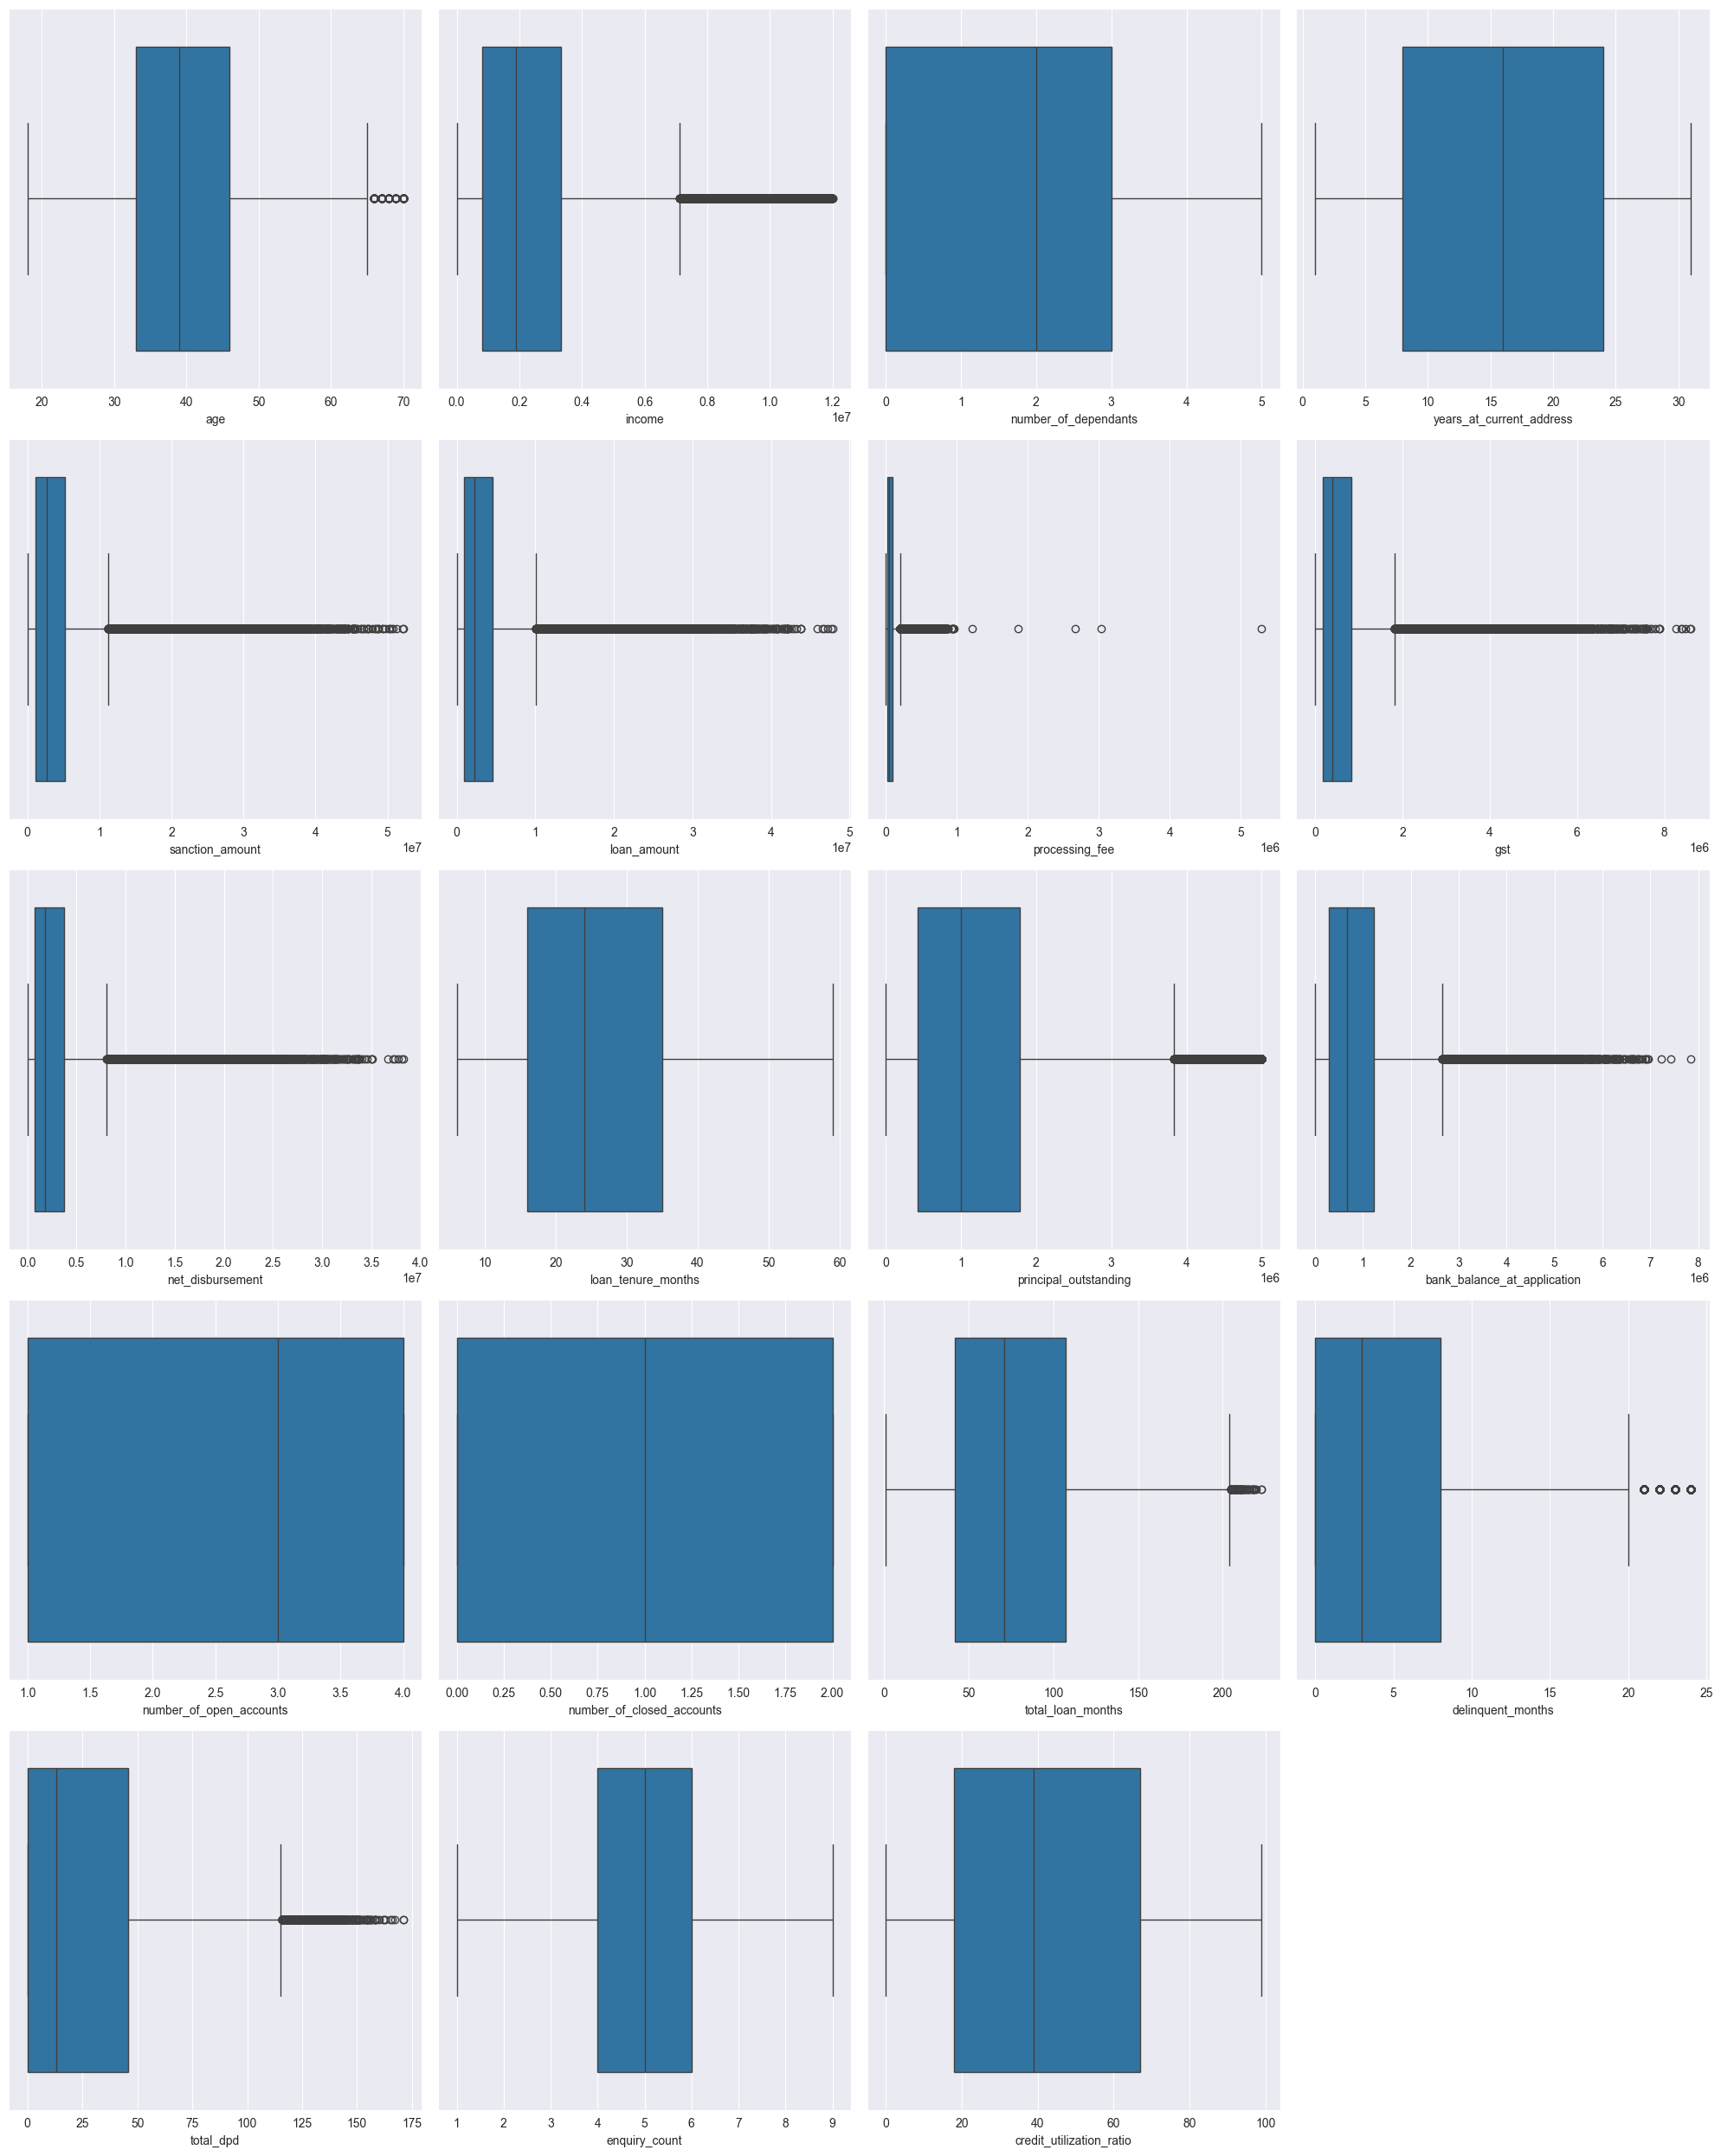

In [18]:
# Set up the subplot grid dimensions
num_cols = 4
num_plots = len(cols_continuous)
num_row = (num_cols + num_plots - 1) // num_cols

# Create the subplots
fig, axs = plt.subplots(num_row, num_cols, figsize = (5*num_cols, 5*num_row))

# Loop through continuous columns and create a box plot for each
for i, col in enumerate(cols_continuous):
    ax = axs.flatten()[i]
    sns.boxplot(x=df_train[col], ax=ax)

# Hide any unused subplots
for j in range(num_plots, num_row * num_cols):
    axs.flatten()[j].set_visible(False)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## 📊 Visualizing Feature Distributions with Histograms
The histograms show that most financial features (`income`, `loan_amount`, etc.) are heavily right-skewed, with the majority of customers having lower values. In contrast, `age` has a more uniform distribution.
> 💡 **Business Insight:** The right-skewed nature of financial data is typical and indicates that high-income or high-loan-amount customers are rare. This skewness is an important characteristic for the model to learn.

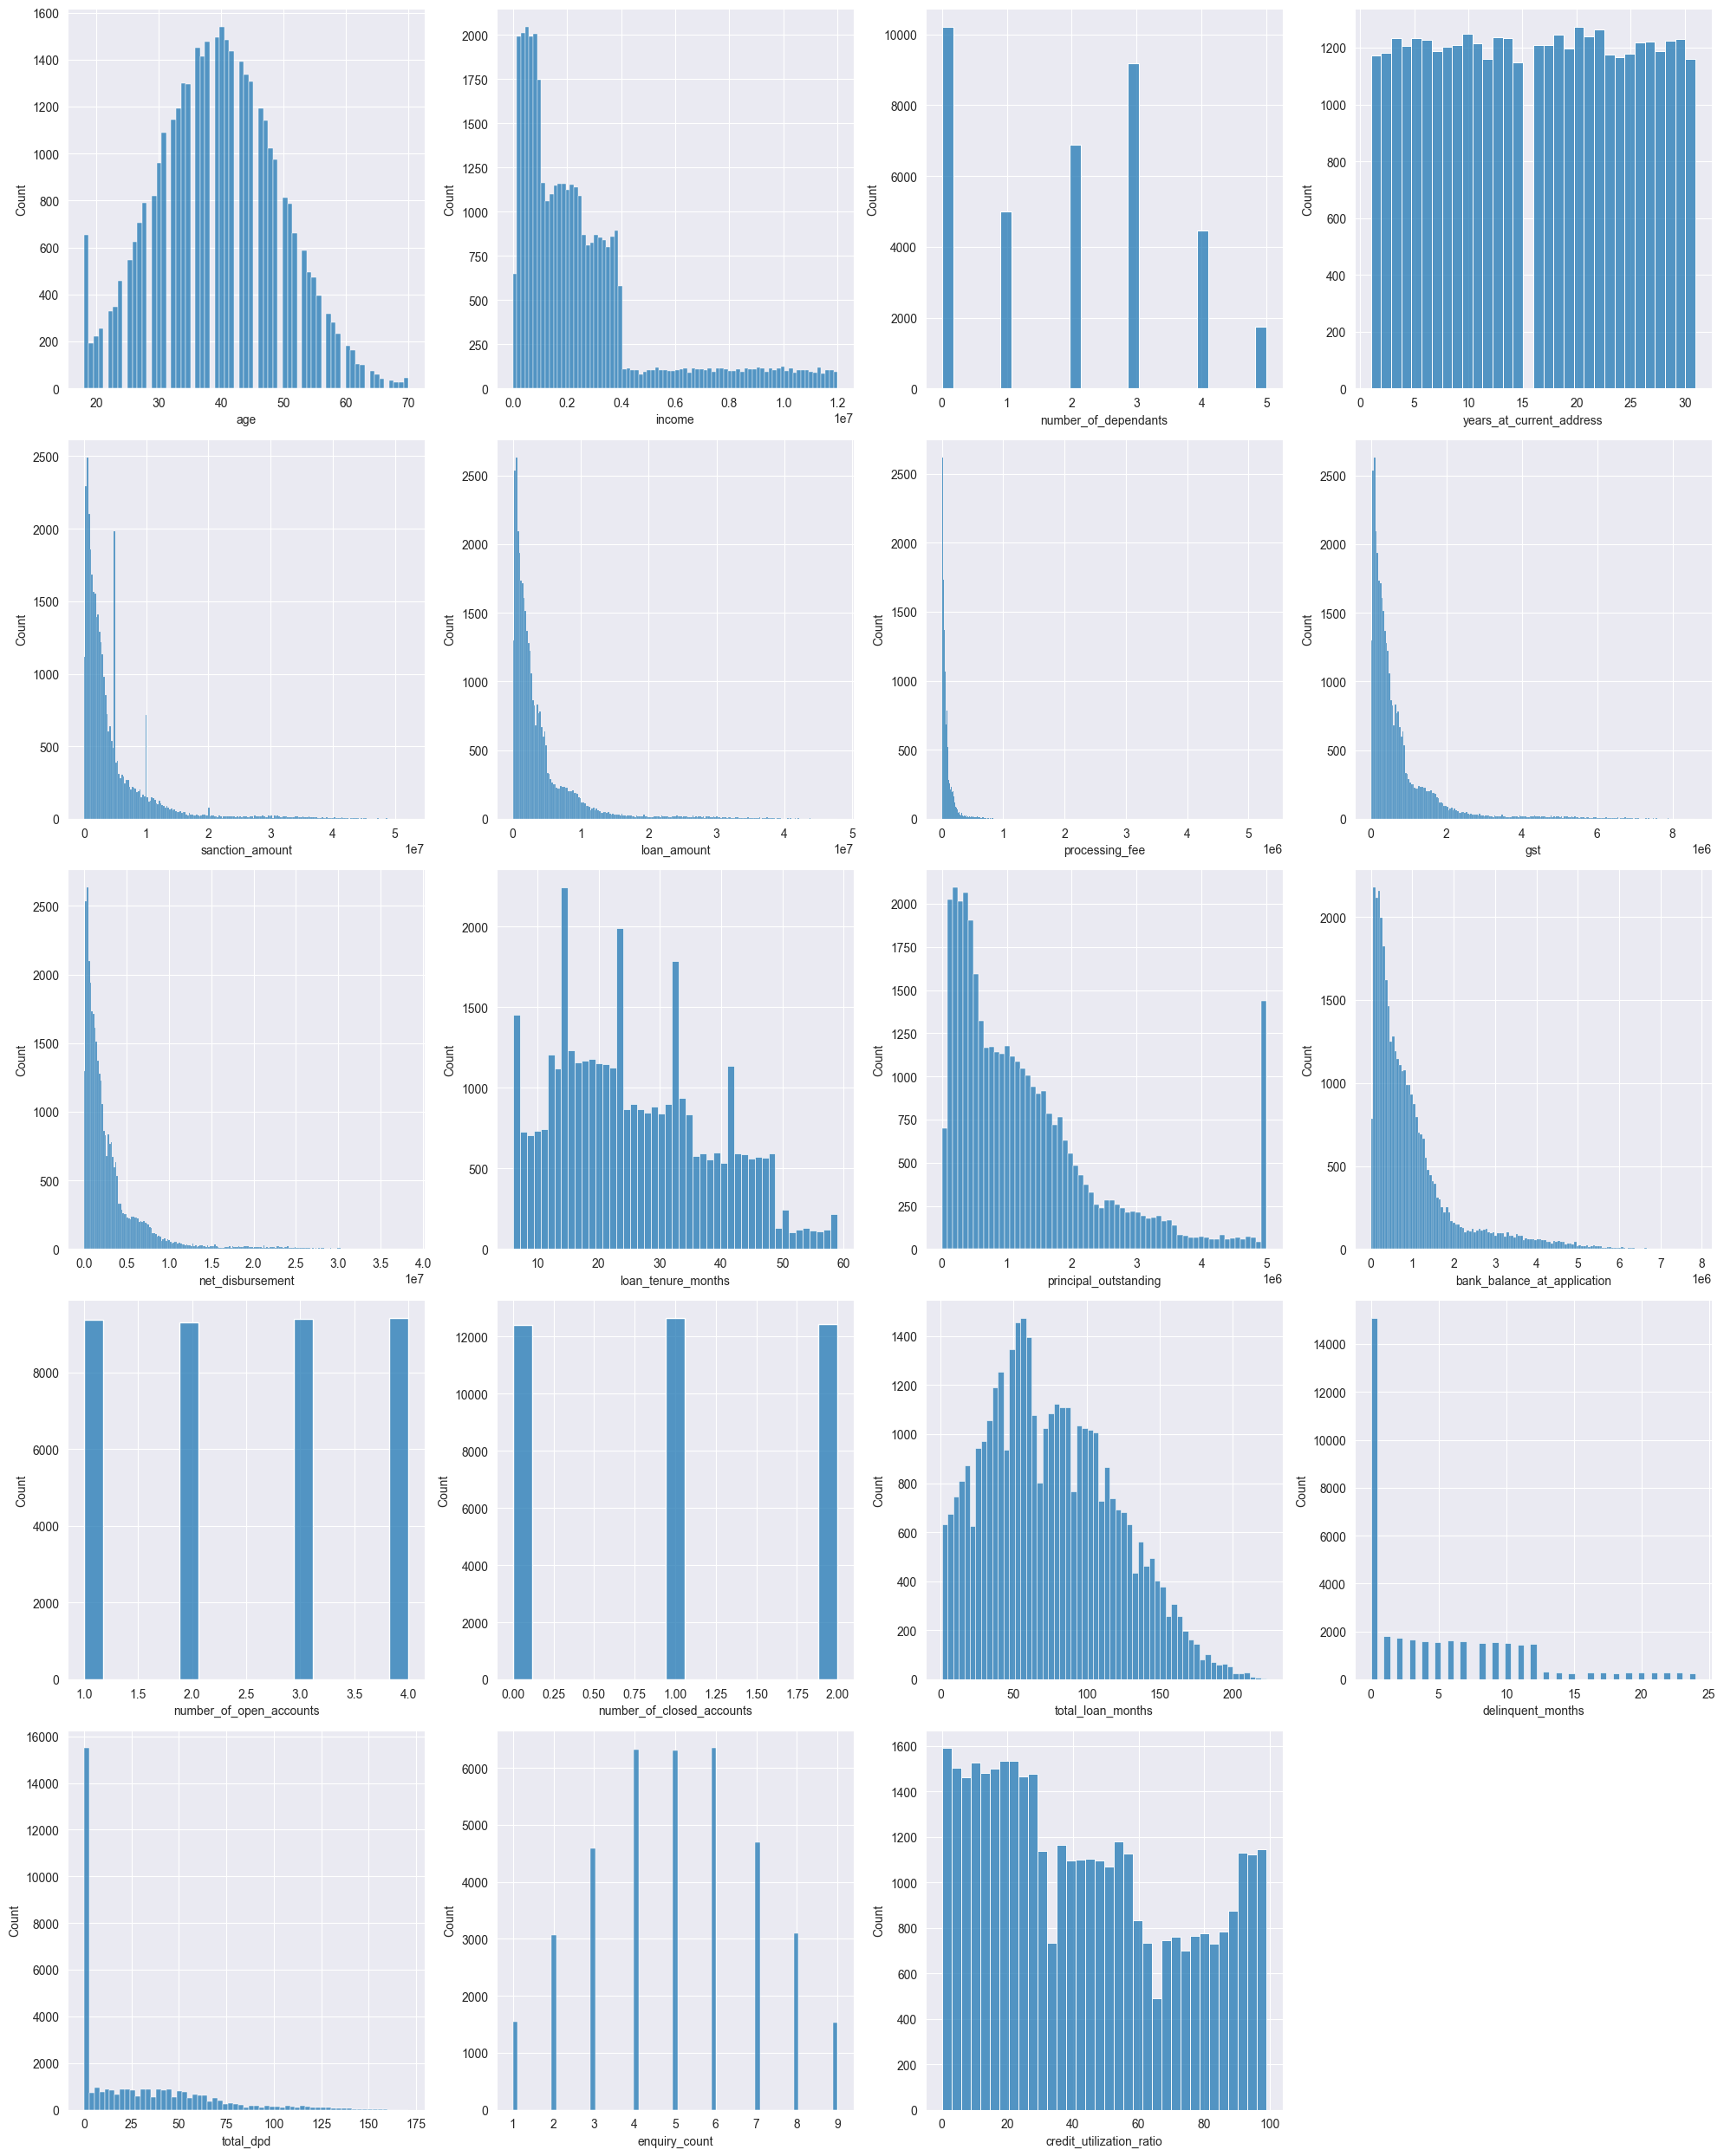

In [19]:
# Create the subplot grid for histograms
fig, axs = plt.subplots(num_row, num_cols, figsize = (5*num_cols, 5*num_row))

# Loop through continuous columns and create a histogram for each
for i, col in enumerate(cols_continuous):
    ax = axs.flatten()[i]
    sns.histplot(x=df_train[col], ax=ax)

# Hide any unused subplots
for j in range(num_plots, num_row * num_cols):
    axs.flatten()[j].set_visible(False)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## 📈 Histograms of Continuous Features — Key Observations
**Pattern:** The distributions for most financial features (`income`, `loan_amount`, `sanction_amount`) are heavily right-skewed, with a high frequency of values clustered at the lower end and a long tail of higher values.
**Standout Values:** The `age` distribution is more uniform, while `loan_tenure_months` shows distinct peaks at common loan term intervals (e.g., 12, 24, 36 months). `delinquent_months` and `total_dpd` are concentrated at zero.
**Credit Risk Meaning:** The right-skewed data is typical for financial information and confirms that high-income/high-loan customers are a minority. The concentration at zero for delinquency metrics indicates that most customers have a clean payment history.
> ✅ **Green Flag:** The high concentration at zero for delinquency-related features suggests a generally low-risk portfolio, but it also reinforces the importance of these features when they are non-zero.

In [20]:
# Get descriptive statistics for the 'processing_fee' column
df_train.processing_fee.describe()

count     37500.0000
mean      80290.6765
std      113128.1399
min           0.0000
25%       19220.0000
50%       44600.0000
75%       92420.0000
max     5293543.5242
Name: processing_fee, dtype: float64

In [21]:
# Find the record with the maximum processing fee
df_train[df_train.processing_fee==df_train.processing_fee.max()][['loan_amount', 'processing_fee']]

,loan_amount,processing_fee
9898,3626000,5293543.5242


In [22]:
# Identify records where the processing fee is more than 3% of the loan amount
df_train[(df_train.processing_fee/df_train.loan_amount) > 0.03][['loan_amount', 'processing_fee']]

,loan_amount,processing_fee
23981,2234000,2669791.0231
28174,966000,1214492.6731
47089,1738000,1858964.7679
29305,2616000,3036378.0053
9898,3626000,5293543.5242


In [23]:
# Filter out the identified outliers from the training and testing sets
df_train_1 = df_train[(df_train.processing_fee/df_train.loan_amount) < 0.03].copy()
df_test_1 = df_test[(df_test.processing_fee/df_test.loan_amount) < 0.03].copy()

In [24]:
# Apply the same outlier removal to the original test set
df_test = df_test[df_test.processing_fee/df_test.loan_amount<0.03].copy()
df_test.shape

(12497, 33)

In [25]:
# Check the shape of the cleaned test set
df_test_1.shape

(12497, 33)

## 📊 Data Cleaning: Standardizing Categorical Values
A typo ('Personaal') was found in the `loan_purpose` column and corrected to 'Personal' in both train and test sets. This ensures the category is treated as a single entity by the model.
> 💡 **Business Insight:** This simple data cleaning step is crucial for model accuracy. It prevents the model from incorrectly treating a typo as a separate, rare category, which would fragment the data and weaken the feature's predictive power.

In [26]:
# Loop through categorical columns and print their unique values
for col in cols_cats:
    print(col,'-->',df_train_1[col].unique())

gender --> ['M' 'F']
marital_status --> ['Married' 'Single']
employment_status --> ['Self-Employed' 'Salaried']
residence_type --> ['Owned' 'Mortgage' 'Rented']
city --> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state --> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode --> [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose --> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type --> ['Secured' 'Unsecured']
default --> [0 1]


In [27]:
# Correct the typo 'Personaal' to 'Personal' in the 'loan_purpose' column
df_train_1['loan_purpose'] = df_train_1['loan_purpose'].replace('Personaal', 'Personal')
df_test_1['loan_purpose'] = df_test_1['loan_purpose'].replace('Personaal', 'Personal')
# Verify the correction
print('train', df_train_1.loan_purpose.unique())
print('test', df_test_1.loan_purpose.unique())

train ['Home' 'Education' 'Personal' 'Auto']
test ['Home' 'Education' 'Auto' 'Personal']


## 📊 EDA: Feature Distributions by Default Status
The KDE plots show a clear separation in distributions for defaulters vs. non-defaulters in several features. For `sanction_amount`, `delinquent_months`, and `total_dpd`, the distribution for defaulters (blue curve) is shifted to the right, indicating they tend to have higher values.
> 💡 **Business Insight:** This visual evidence confirms that higher loan amounts and a history of delinquency are strong indicators of default risk. These features will likely be very important in the final model.

In [28]:
# Display the list of continuous columns
cols_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

In [29]:
# Get descriptive statistics for 'age', grouped by the 'default' status
df_train_1.groupby("default")['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34265.0000,39.7677,9.8802,18.0000,33.0000,40.0000,46.0000,70.0000
1,3223.0000,37.1247,9.2902,18.0000,31.0000,37.0000,44.0000,70.0000


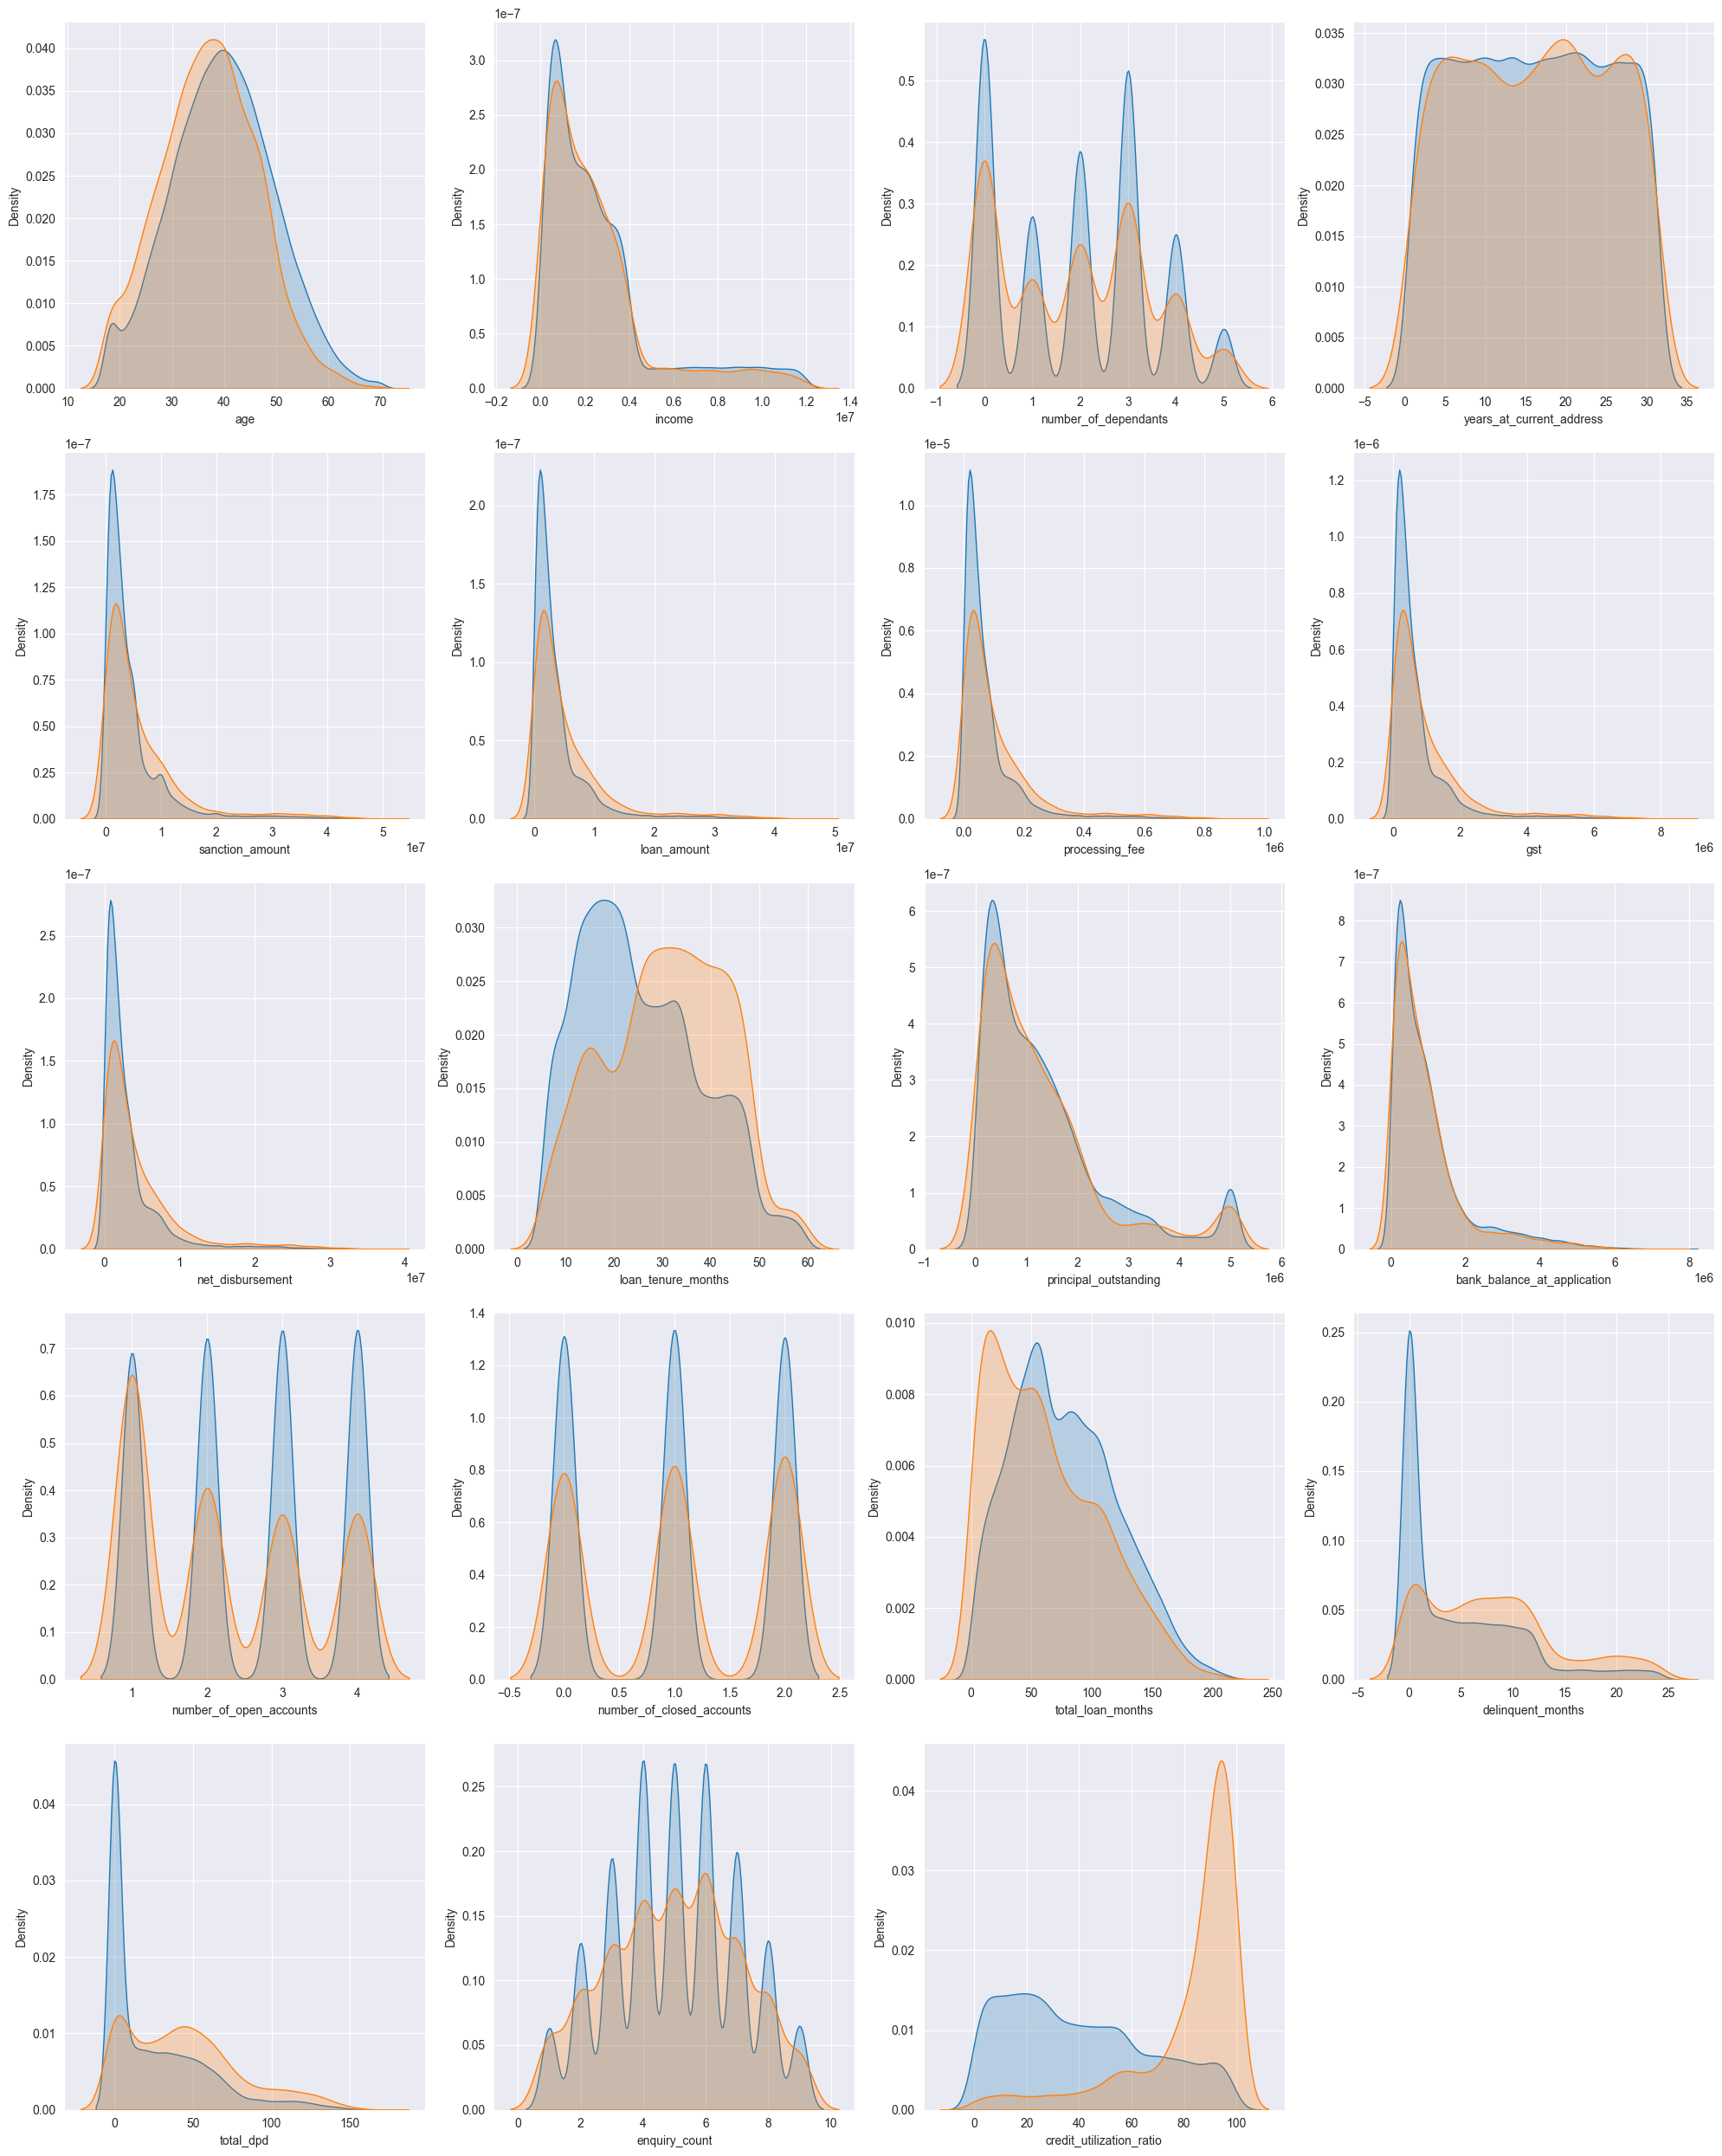

In [30]:
# Create subplots for KDE plots
fig, axs = plt.subplots(num_row, num_cols, figsize = (5*num_cols, 5*num_row))

# Loop through continuous columns and create a KDE plot for each, separated by 'default' status
for i, col in enumerate(cols_continuous):
    ax = axs.flatten()[i]
    sns.kdeplot(df_train_1[df_train_1.default == 0][col] ,ax=ax , fill=True, label='Default=0')
    sns.kdeplot(df_train_1[df_train_1.default == 1][col] ,ax=ax , fill=True, label='Default=1')

# Hide unused subplots
for j in range(num_plots, num_row * num_cols):
    axs.flatten()[j].set_visible(False)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## 📊 Feature Engineering: Loan-to-Income (LTI) Ratio
A new feature, `loan_to_income`, was created. The KDE plot shows a clear separation, with the distribution for defaulters (`Default=1`) peaking at a higher LTI ratio compared to non-defaulters.
> 💡 **Business Insight:** A higher LTI ratio indicates a greater debt burden relative to a customer's earnings. This engineered feature effectively captures this financial strain, making it a strong predictor of default risk.

In [31]:
# Create the 'loan_to_income' ratio feature
df_train_1['loan_to_income'] = df_train_1['loan_amount'] / df_train_1['income']
df_test_1['loan_to_income'] = df_test_1['loan_amount'] / df_test_1['income']

# Get descriptive statistics for the new feature
df_train_1.loan_to_income.describe()

count   37488.0000
mean        1.5567
std         0.9737
min         0.2980
25%         0.7685
50%         1.1598
75%         2.4611
max         4.5652
Name: loan_to_income, dtype: float64

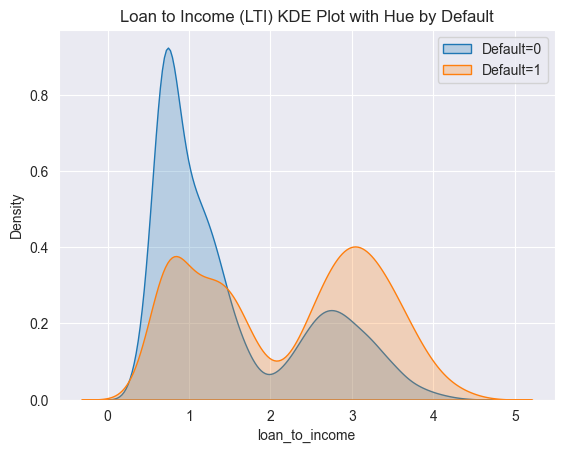

In [32]:
# Plot the KDE for 'loan_to_income', separated by 'default' status
sns.kdeplot(df_train_1[df_train_1.default == 0]['loan_to_income'] , fill=True, label='Default=0')
sns.kdeplot(df_train_1[df_train_1.default == 1]['loan_to_income'] , fill=True, label='Default=1')
plt.title('Loan to Income (LTI) KDE Plot with Hue by Default')
plt.legend()
plt.show()

## 📊 Feature Engineering: Delinquent Ratio
The `delinquent_ratio` feature was created to normalize delinquency. The KDE plot shows a dramatic separation: the distribution for non-defaulters is almost entirely concentrated at zero, while defaulters show a wide distribution of non-zero ratios.
> 💡 **Business Insight:** This feature is an extremely powerful predictor. It demonstrates that any history of delinquency as a proportion of loan history is a massive red flag for future default.

In [33]:
# Create the 'delinquent_ratio' feature
df_train_1['delinquent_ratio'] = df_train_1['delinquent_months']*100 / df_train_1['total_loan_months']
df_test_1['delinquent_ratio'] = df_test_1['delinquent_months']*100 / df_test_1['total_loan_months']
# Display a sample of the new feature
df_train_1[['delinquent_months', 'loan_to_income', 'delinquent_ratio']].head()

,delinquent_months,loan_to_income,delinquent_ratio
12746,20,2.0696,13.1579
32495,10,1.6070,6.2500
43675,12,3.5355,22.2222
9040,0,1.1300,0.0000
13077,0,0.4981,0.0000


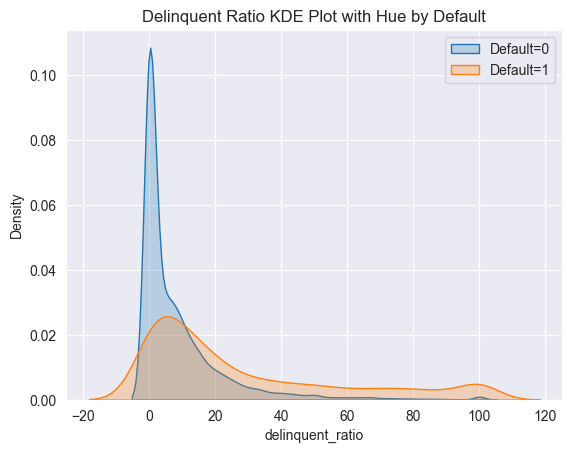

In [34]:
# Plot the KDE for 'delinquent_ratio', separated by 'default' status
sns.kdeplot(df_train_1[df_train_1.default == 0]['delinquent_ratio'] , fill=True, label='Default=0')
sns.kdeplot(df_train_1[df_train_1.default == 1]['delinquent_ratio'] , fill=True, label='Default=1')
plt.title('Delinquent Ratio KDE Plot with Hue by Default')
plt.legend()
plt.show()

## 📈 Delinquent Ratio Distribution — Key Observations
**Pattern:** The plot shows an extremely stark separation between the two classes for the `delinquent_ratio` feature.
**Standout Values:** The distribution for non-defaulters (Default=0) is almost entirely a sharp spike at zero. In contrast, the distribution for defaulters (Default=1) is spread out across a wide range of positive values.
**Credit Risk Meaning:** This is a powerful visual confirmation that having any history of delinquency is a massive indicator of default risk. A non-zero `delinquent_ratio` is a major red flag.
> ✅ **Green Flag:** This feature is likely to be one of the most important predictors in the model due to the dramatic separation it provides.

In [35]:
# Create the 'avg_dpd_per_delinquent' feature, handling division by zero
df_train_1['avg_dpd_per_delinquent'] = np.where(
    df_train_1['delinquent_months'] != 0, # Condition to avoid division by zero
    df_train_1['total_dpd'] / df_train_1['delinquent_months'],
    0
)

df_test_1['avg_dpd_per_delinquent'] = np.where(
    df_test_1['delinquent_months'] != 0, # Condition to avoid division by zero
    df_test_1['total_dpd'] / df_test_1['delinquent_months'],
    0
)

# Get descriptive statistics for the new feature
df_train_1['avg_dpd_per_delinquent'].describe()

count   37488.0000
mean        3.2842
std         2.9067
min         0.0000
25%         0.0000
50%         4.3333
75%         5.7418
max        10.0000
Name: avg_dpd_per_delinquent, dtype: float64

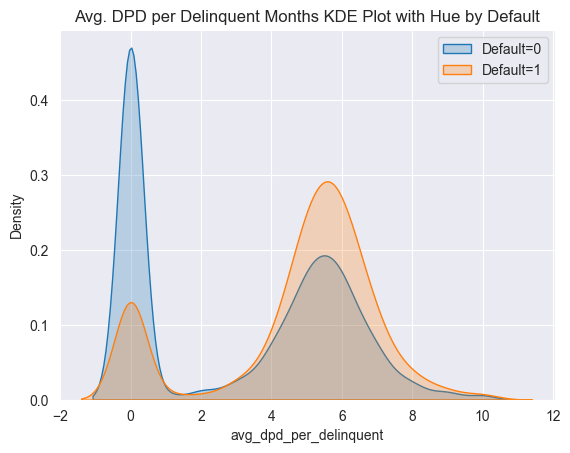

In [36]:
# Plot the KDE for 'avg_dpd_per_delinquent', separated by 'default' status
sns.kdeplot(df_train_1[df_train_1.default == 0]['avg_dpd_per_delinquent'] , fill=True, label='Default=0')
sns.kdeplot(df_train_1[df_train_1.default == 1]['avg_dpd_per_delinquent'] , fill=True, label='Default=1')
plt.title('Avg. DPD per Delinquent Months KDE Plot with Hue by Default')
plt.legend()
plt.show()

## 📈 Average DPD per Delinquency Distribution — Key Observations
**Pattern:** The plot for `avg_dpd_per_delinquent` shows a clear separation, with the distribution for defaulters shifted to the right.
**Standout Values:** While both distributions peak near zero, the tail for defaulters (Default=1) is much heavier and extends further into higher values, indicating more severe delays.
**Credit Risk Meaning:** This feature successfully captures the *severity* of delinquency. It shows that customers who default not only have a history of late payments but their payments are, on average, significantly more delayed than those of non-defaulters.
> ✅ **Green Flag:** This feature adds a valuable dimension beyond just the frequency of delinquency, likely improving the model's ability to distinguish between minor and major risk.

In [37]:
# Drop identifier columns as they have no predictive value
df_train_2 = df_train_1.drop(['cust_id', 'loan_id'], axis=1)
df_test_2 = df_test_1.drop(['cust_id', 'loan_id'], axis=1)

In [38]:
# Drop columns that were used to create engineered features or are otherwise redundant
drop_cols = ['disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 'total_loan_months', 'delinquent_months', 'total_dpd']
df_train_3 = df_train_2.drop(drop_cols, axis=1)
df_test_3 = df_test_2.drop(drop_cols, axis=1)
# Display the remaining columns
df_train_3.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquent_ratio', 'avg_dpd_per_delinquent'],
      dtype='object')

In [39]:
# Select only the numeric columns for scaling
df_train_3.select_dtypes(['int64', 'float64']).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquent_ratio', 'avg_dpd_per_delinquent'],
      dtype='object')

## 📊 Feature Scaling with MinMaxScaler
Numerical features were scaled to a range between 0 and 1. The scaler was fitted on the training data and then used to transform both the train and test sets.
> 💡 **Business Insight:** Scaling ensures that features with large ranges (like `sanction_amount`) do not dominate the model's learning process over features with smaller ranges (like `number_of_dependants`), leading to a more balanced and accurate model.

In [40]:
# Separate features and target for the final modeling dataset
X_train = df_train_3.drop('default', axis=1)
y_train = df_train_3['default']

# Identify the columns that need to be scaled (numeric, excluding identifiers and target)
cols_to_scale = df_train_3.select_dtypes(['int64', 'float64']).columns.drop(['default', 'zipcode'])

# Initialize the MinMaxScaler
mms_scaler = MinMaxScaler()
# Fit the scaler on the training data and transform it
X_train[cols_to_scale] = mms_scaler.fit_transform(X_train[cols_to_scale])
# Display the first 5 rows of the scaled data
X_train.head(5)

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_purpose,loan_type,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquent
12746,0.7885,M,Married,Self-Employed,0.6000,Owned,0.9667,Hyderabad,Telangana,500001,Home,Secured,0.6343,0.4896,0.4896,0.4896,0.4151,1.0000,0.6134,1.0000,1.0000,0.3750,0.3636,0.4152,0.1316,0.5900
32495,0.5000,F,Single,Salaried,0.0000,Owned,0.8667,Mumbai,Maharashtra,400001,Education,Secured,0.0212,0.0229,0.0229,0.0229,0.8302,0.0870,0.0252,0.6667,0.5000,0.5000,0.0505,0.3068,0.0625,0.6200
43675,0.3846,M,Single,Salaried,0.0000,Mortgage,0.8333,Chennai,Tamil Nadu,600001,Home,Secured,0.2176,0.2353,0.2353,0.2353,0.4906,0.3266,0.1743,0.0000,0.5000,0.3750,0.0000,0.7587,0.2222,0.5583
9040,0.4615,M,Married,Salaried,0.4000,Mortgage,0.9667,Bangalore,Karnataka,560001,Education,Secured,0.0435,0.0343,0.0343,0.0343,0.6415,0.1991,0.0775,0.6667,0.0000,0.8750,0.8788,0.1950,0.0000,0.0000
13077,0.7692,M,Married,Self-Employed,0.8000,Owned,0.9333,Pune,Maharashtra,411001,Personal,Unsecured,0.0210,0.0178,0.0178,0.0178,0.1698,0.1242,0.0723,0.0000,1.0000,0.0000,0.7172,0.0469,0.0000,0.0000


In [41]:
# Check descriptive statistics of the scaled training data
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquent
count,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000,37488.0000
mean,0.4142,0.3889,0.4999,418876.2401,0.0888,0.0825,0.0825,0.0825,0.3766,0.2616,0.1236,0.5009,0.5006,0.5011,0.4387,0.2950,0.1033,0.3284
std,0.1896,0.3072,0.2974,169029.8683,0.1201,0.1125,0.1125,0.1125,0.2349,0.2445,0.1333,0.3730,0.4070,0.2537,0.2969,0.2282,0.1730,0.2907
min,0.0000,0.0000,0.0000,110001.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.2885,0.0000,0.2333,302001.0000,0.0206,0.0190,0.0190,0.0190,0.1887,0.0780,0.0342,0.0000,0.0000,0.3750,0.1818,0.1103,0.0000,0.0000
50%,0.4038,0.4000,0.5000,400001.0000,0.0494,0.0455,0.0455,0.0455,0.3396,0.1939,0.0825,0.6667,0.5000,0.5000,0.3939,0.2019,0.0368,0.4333
75%,0.5385,0.6000,0.7667,560001.0000,0.0980,0.0956,0.0956,0.0956,0.5472,0.3524,0.1552,1.0000,1.0000,0.6250,0.6768,0.5069,0.1295,0.5742
max,1.0000,1.0000,1.0000,700001.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [42]:
# Separate features and target for the test set
X_test = df_test_3.drop('default', axis=1)
y_test = df_test_3['default']

# Identify the columns to scale in the test set
cols_to_scale = df_test_3.select_dtypes(['int64', 'float64']).columns.drop(['default', 'zipcode'])

# Transform the test data using the scaler that was FIT ON THE TRAINING DATA
X_test[cols_to_scale] = mms_scaler.transform(X_test[cols_to_scale])
# Check descriptive statistics of the scaled test data
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquent
count,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000,12497.0000
mean,0.4150,0.3849,0.5027,419759.8221,0.0892,0.0828,0.0828,0.0828,0.3751,0.2646,0.1249,0.4973,0.5004,0.5015,0.4360,0.2937,0.1061,0.3339
std,0.1888,0.3069,0.2981,168845.3532,0.1208,0.1129,0.1129,0.1129,0.2338,0.2453,0.1347,0.3726,0.4072,0.2536,0.2954,0.2263,0.1731,0.2897
min,0.0000,0.0000,0.0000,110001.0000,-0.0000,-0.0001,-0.0001,-0.0001,0.0000,0.0002,0.0007,0.0000,0.0000,0.0000,0.0000,-0.0004,0.0000,0.0000
25%,0.2885,0.0000,0.2333,302001.0000,0.0210,0.0194,0.0194,0.0194,0.1887,0.0797,0.0342,0.0000,0.0000,0.3750,0.1818,0.1118,0.0000,0.0000
50%,0.4231,0.4000,0.5000,411001.0000,0.0502,0.0462,0.0462,0.0462,0.3396,0.1982,0.0840,0.3333,0.5000,0.5000,0.3939,0.2024,0.0421,0.4400
75%,0.5385,0.6000,0.7667,560001.0000,0.0974,0.0949,0.0949,0.0949,0.5472,0.3569,0.1578,0.6667,1.0000,0.6250,0.6768,0.5002,0.1339,0.5750
max,1.0000,1.0000,1.0000,700001.0000,0.9812,0.9637,0.9637,0.9637,1.0000,1.0000,0.9392,1.0000,1.0000,1.0000,1.0000,1.0061,1.0000,1.0000


## 📊 Multicollinearity Check with VIF
The initial VIF calculation shows extremely high values for financial features, with `net_disbursement` at 1043, `sanction_amount` at 921, and `principal_outstanding` at 122. This confirms severe multicollinearity.
> 💡 **Business Insight:** High VIF scores indicate that these features are highly correlated and carry redundant information. Keeping them would make the model's coefficients unstable and unreliable. This justifies their removal.

In [43]:
# Import the VIF function
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Define a function to calculate VIF for a DataFrame
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

# Select numeric columns and calculate their VIF scores
nc = X_train.select_dtypes(['int64', 'float64']).columns
calculate_vif(X_train[nc]).sort_values(by=['VIF'], ascending=False)

C:\Users\Aman Sharma\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
6,gst,inf
5,processing_fee,inf
7,net_disbursement,inf
4,sanction_amount,101.0881
9,principal_outstanding,16.3313
10,bank_balance_at_application,9.3570
15,loan_to_income,7.0207
13,enquiry_count,6.4607
8,loan_tenure_months,6.1883
0,age,5.7946


## 📊 Removing Highly Collinear Features
After dropping five highly correlated financial features, the VIF scores for all remaining numeric features are now below 2.5. For example, `credit_utilization_ratio` has a VIF of 1.01 and `loan_to_income` is at 1.03.
> 💡 **Business Insight:** With all VIF scores well below the common threshold of 5, the model is now free from the negative effects of multicollinearity. This leads to more stable and interpretable feature importances.

In [44]:
# Define the list of columns to drop based on high VIF
drop_cols_for_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement', 'principal_outstanding']
# Drop these columns from the training data
X_train_1 = X_train.drop(drop_cols_for_vif, axis=1)
# Recalculate VIF on the remaining numeric columns to confirm the fix
numeric_cals = X_train_1.select_dtypes(['int64', 'float64']).columns
vif_df = calculate_vif(X_train_1[numeric_cals])
vif_df

,Column,VIF
0,age,5.5329
1,number_of_dependants,2.7320
2,years_at_current_address,3.4463
3,zipcode,5.6099
4,loan_tenure_months,6.0284
5,bank_balance_at_application,1.8099
6,number_of_open_accounts,4.3583
7,number_of_closed_accounts,2.3865
8,enquiry_count,6.4393
9,credit_utilization_ratio,2.9462


In [45]:
# Display the columns of the test DataFrame
df_test.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

In [46]:
# Check the mean credit utilization ratio grouped by default status
# This is a sanity check to ensure the feature behaves as expected (higher for defaulters)
print(df_train_3.groupby('default')['credit_utilization_ratio'].mean())
# Bad customers should have higher ratio — if gap is too extreme, investigate

default
0   39.8429
1   81.5271
Name: credit_utilization_ratio, dtype: float64


## 📊 Correlation Heatmap
The heatmap shows the correlations between the final set of numeric features. `delinquent_ratio` has the highest positive correlation with `default` (0.33), while `loan_to_income` (0.11) and `avg_dpd_per_delinquent` (0.10) also show a notable positive relationship.
> 💡 **Business Insight:** The heatmap visually confirms that our engineered features related to delinquency and debt burden are the most predictive indicators of default, validating the feature engineering efforts.

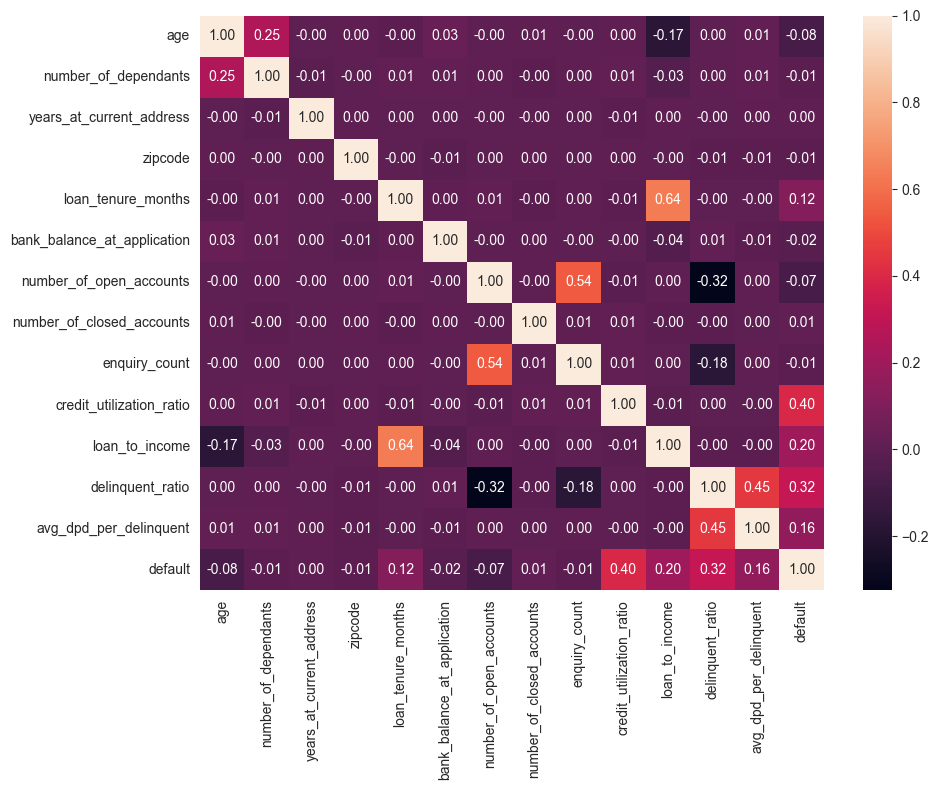

In [47]:
# Get the names of the selected numeric features after VIF reduction
selected_numeric_features_vif = vif_df.Column.values
# Create a correlation matrix for these features plus the target variable
plt.figure(figsize=(10, 8))
cm = df_train_3[numeric_cals.append(pd.Index(['default']))].corr()
# Plot the correlation matrix as a heatmap
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.tight_layout()
plt.show()

## 📊 Feature Selection with Information Value (IV)
The IV calculation ranks features by predictive power. `delinquent_ratio` (IV=1.13) and `avg_dpd_per_delinquent` (IV=0.48) are identified as very strong predictors. In contrast, features like `gender` (IV=0.0001) and `marital_status` (IV=0.0003) have negligible predictive power.
> 💡 **Business Insight:** IV provides a quantitative, industry-standard method for feature selection. By selecting features with IV > 0.02, we ensure the model focuses only on variables that have a meaningful impact on credit risk.

In [49]:
# Define a function to calculate Weight of Evidence (WOE) and Information Value (IV)
def calculate_wof_vi(df, feature, target):
    # Group by the feature and calculate counts and sums of the target
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad'] = grouped['total'] - grouped['good']

    # Calculate total good and bad counts
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    # Calculate percentage of good and bad in each group
    grouped['good_pct'] = grouped['good']/total_good
    grouped['bad_pct'] = grouped['bad']/total_bad

    # Replace 0s to avoid division by zero in log calculation
    grouped['good_pct'] = grouped['good_pct'].replace(0, 1e-10)
    grouped['bad_pct'] = grouped['bad_pct'].replace(0, 1e-10)

    # Calculate WOE and IV
    grouped['WOE'] = np.log(grouped['good_pct']/grouped['bad_pct'])
    grouped['IV'] = grouped['WOE']*(grouped['good_pct'] - grouped['bad_pct'])

    # Sum the IV for the total Information Value of the feature
    total_iv = grouped['IV'].sum()

    return grouped, total_iv

# Calculate IV for a single feature as an example
grouped, iv = calculate_wof_vi(pd.concat([X_train_1, y_train], axis=1), 'loan_purpose', 'default')
print(iv)
grouped

0.3691197842282755


,total,good,bad,good_pct,bad_pct,WOE,IV
loan_purpose,,,,,,,
Auto,7447,327,7120,0.1015,0.2078,-0.7169,0.0762
Education,5620,559,5061,0.1734,0.1477,0.1606,0.0041
Home,11304,1734,9570,0.5380,0.2793,0.6556,0.1696
Personal,13117,603,12514,0.1871,0.3652,-0.6689,0.1191


In [50]:
# Display info for the training DataFrame
X_train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  float64
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  float64
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  float64
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  int64  
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  loan_tenure_months           37488 non-null  float64
 13  bank_balance_at_a

In [51]:
# Create a dictionary to store the IV for each feature
iv_features = {}

# Loop through all features to calculate their IV
for feature in X_train_1.columns:
    # For categorical features
    if X_train_1[feature].dtype == 'object':
        _, iv = calculate_wof_vi(pd.concat([X_train_1, y_train], axis=1), feature, 'default')
    # For numerical features, first bin them into 10 groups
    else:
        X_bins = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_wof_vi(pd.concat([X_bins, y_train], axis=1), feature, 'default')

    iv_features[feature] = iv

iv_features

{'age': np.float64(0.0890689462679479),
 'gender': np.float64(0.00047449502170914947),
 'marital_status': np.float64(0.001129766845390142),
 'employment_status': np.float64(0.003953046301722585),
 'number_of_dependants': np.float64(0.0019380899135053508),
 'residence_type': np.float64(0.246745268718145),
 'years_at_current_address': np.float64(0.0020800513608156363),
 'city': np.float64(0.0019059578709781529),
 'state': np.float64(0.0019005589806779287),
 'zipcode': np.float64(0.0016677413243392572),
 'loan_purpose': np.float64(0.3691197842282755),
 'loan_type': np.float64(0.16319324904149224),
 'loan_tenure_months': np.float64(0.21893515090196278),
 'bank_balance_at_application': np.float64(0.0063187993277516365),
 'number_of_open_accounts': np.float64(0.08463134083005877),
 'number_of_closed_accounts': np.float64(0.0011964272592421567),
 'enquiry_count': np.float64(0.007864214085342608),
 'credit_utilization_ratio': np.float64(2.352965568168245),
 'loan_to_income': np.float64(0.47572

In [52]:
# Convert the IV dictionary to a DataFrame for easier sorting and viewing
iv_df = pd.DataFrame(list(iv_features.items()), columns=['feature', 'iv'])
# Sort the DataFrame by IV in descending order
iv_df.sort_values(by='iv', inplace=True, ascending=False, ignore_index=True)
iv_df

,feature,iv
0,credit_utilization_ratio,2.3530
1,delinquent_ratio,0.7166
2,loan_to_income,0.4757
3,avg_dpd_per_delinquent,0.4018
4,loan_purpose,0.3691
5,residence_type,0.2467
6,loan_tenure_months,0.2189
7,loan_type,0.1632
8,age,0.0891
9,number_of_open_accounts,0.0846


## 📊 Final Feature Selection & Encoding
Based on an IV threshold of >0.02, the feature set was reduced to the most predictive variables. These features were then one-hot encoded, expanding the final feature space to 18 columns for model training.
> 💡 **Business Insight:** This final, encoded dataset is highly optimized, containing only the most powerful predictors in a format ready for machine learning algorithms.

In [53]:
# Select features with an Information Value greater than 0.02
selective_features_iv = [feature for feature, iv in iv_features.items() if iv > 0.02]
selective_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquent_ratio',
 'avg_dpd_per_delinquent']

In [54]:
# Create new DataFrames with only the selected features
X_train_reduced = X_train_1[selective_features_iv]
X_test_reduced = X_test[selective_features_iv]

In [55]:
# Display the head of the reduced training data
X_train_reduced.head()

,age,residence_type,loan_purpose,loan_type,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquent
12746,0.7885,Owned,Home,Secured,0.4151,1.0000,0.3636,0.4152,0.1316,0.5900
32495,0.5000,Owned,Education,Secured,0.8302,0.6667,0.0505,0.3068,0.0625,0.6200
43675,0.3846,Mortgage,Home,Secured,0.4906,0.0000,0.0000,0.7587,0.2222,0.5583
9040,0.4615,Mortgage,Education,Secured,0.6415,0.6667,0.8788,0.1950,0.0000,0.0000
13077,0.7692,Owned,Personal,Unsecured,0.1698,0.0000,0.7172,0.0469,0.0000,0.0000


In [56]:
# Apply one-hot encoding to the categorical features in the reduced datasets
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)

In [57]:
# Check the shape of the final encoded training data
X_train_encoded.shape

(37488, 13)

In [58]:
# Display a specific row from the encoded test data
X_test_encoded.loc[19205]

age                        0.3462
loan_tenure_months         0.7547
number_of_open_accounts    0.3333
credit_utilization_ratio   0.9899
loan_to_income             0.5519
delinquent_ratio           0.0000
avg_dpd_per_delinquent     0.0000
residence_type_Owned         True
residence_type_Rented       False
loan_purpose_Education      False
loan_purpose_Home            True
loan_purpose_Personal       False
loan_type_Unsecured         False
Name: 19205, dtype: object

## 📊 Baseline Model: Logistic Regression
The baseline Logistic Regression model achieved a very low recall of 0.13 for the default class (1), while its precision was high at 0.74. This indicates the model is failing to identify most of the actual defaulters.
> 💡 **Business Insight:** This poor recall performance highlights the model's inability to handle the class imbalance. It is too conservative, predicting non-default in most cases, which is not useful for the business goal of proactively identifying risk.

In [59]:
# Import Logistic Regression and classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train_encoded, y_train)

# Make predictions on the test set and print the classification report
y_pred = lr_model.predict(X_test_encoded)
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



## 📊 Baseline Model: Random Forest
The Random Forest model shows a significant improvement over Logistic Regression, with recall for the default class increasing to 0.42. However, this is still well below the desired level for a reliable risk model.
> 💡 **Business Insight:** The improved performance suggests that non-linear relationships exist in the data, which the tree-based Random Forest can capture better than a linear model. However, further tuning is needed to meet the business objective for default detection.

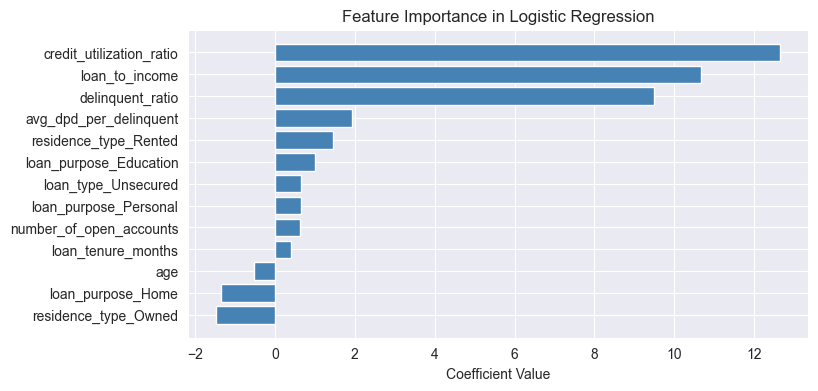

In [60]:
# Get the feature importances (coefficients) from the logistic regression model
feature_importance = lr_model.coef_[0]

# Create a DataFrame to display the feature importances
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plot the feature importances as a horizontal bar chart
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [61]:
# Import the RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
model = RandomForestClassifier()
model.fit(X_train_encoded, y_train)

# Make predictions and print the classification report
y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.71      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



## 📊 Baseline Model: XGBoost
The baseline XGBoost model provides the best initial performance, achieving a recall of 0.51 for the default class with a strong precision of 0.81. This is a substantial improvement over both previous models.
> 💡 **Business Insight:** XGBoost's superior baseline performance makes it the strongest candidate for further optimization. Its ability to handle complex interactions and its built-in regularization are clear advantages for this dataset.

In [62]:
# Import the XGBClassifier
from xgboost import XGBClassifier

# Initialize and train the XGBoost model
model = XGBClassifier()
model.fit(X_train_encoded, y_train)

# Make predictions and print the classification report
y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.75      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.87      0.88     12497
weighted avg       0.96      0.96      0.96     12497



## 📊 Hyperparameter Tuning: XGBoost with RandomizedSearch
The randomized search identified optimal parameters, including `scale_pos_weight=10` and `max_depth=5`. This tuned model dramatically increased the recall for defaulters to 0.89, at the cost of reducing precision to 0.35.
> 💡 **Business Insight:** The tuning successfully optimized the model for the primary business goal: identifying defaulters. The `scale_pos_weight` parameter proved critical in forcing the model to pay more attention to the minority class, even if it leads to more false positives (lower precision).

In [63]:
# Import RandomizedSearchCV and scoring functions
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
import numpy as np

# Define the parameter distribution for Logistic Regression tuning (for comparison)
param_dist = {
    'C': np.logspace(-4, 4, 50),                        # Regularization strength
    'solver': ['lbfgs', 'liblinear', 'saga', 'newton-cg'],             # Optimization algorithm
}

# Initialize the Logistic Regression model
lr = LogisticRegression(max_iter=10000)

# Set up the RandomizedSearchCV for Logistic Regression
search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=50,                # Number of combinations to try
    scoring='f1',
    cv=3,                      # 3-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1                  # Use all CPU cores
)

# Fit the search to the data
search.fit(X_train_encoded, y_train)

# Print the best parameters and score
print("Best Params:", search.best_params_)
print("Best AUC Score:", search.best_score_)

# Evaluate the best model found by the search
best_model = search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
result = classification_report(y_test, y_pred)
print(result)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Params: {'solver': 'lbfgs', 'C': np.float64(159.98587196060572)}
Best AUC Score: 0.7574262449037003
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.83      0.74      0.78      1074

    accuracy                           0.97     12497
   macro avg       0.91      0.86      0.88     12497
weighted avg       0.96      0.97      0.96     12497



In [64]:
# Import the XGBClassifier again for tuning
from xgboost import XGBClassifier

# Define the hyperparameter distribution for XGBoost tuning
param_dist = {
    'n_estimators':      [100, 200, 300, 500, 700],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.02, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.5, 0.6, 0.7, 0.8, 0.9],
    'colsample_bylevel': [0.5, 0.6, 0.7, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5, 7, 10],
    'gamma':             [0, 0.1, 0.3, 0.5, 1.0],
    'reg_alpha':         [0.01, 0.1, 0.5, 1.0, 2.0],
    'reg_lambda':        [0.1, 0.5, 1.0, 2.0, 5.0],
    'scale_pos_weight':  [1, 5, 8, 10, 11, 15], # Key parameter for imbalance
}

# Define monotone constraints if needed (feature should only have a positive or negative effect)
constraints = {
    'credit_utilization_ratio': 0,        # 0 means no constraint
}

# Initialize the XGBoost classifier with the constraints
xgb = XGBClassifier(
    monotone_constraints=constraints
)

# Create a scorer that focuses specifically on the recall of the positive class (1)
recall_scorer_class1 = make_scorer(recall_score, pos_label=1)

# Set up the RandomizedSearchCV for XGBoost
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100, # Number of parameter settings that are sampled
    scoring=recall_scorer_class1, # Optimize for recall of class 1
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the search to the data
search.fit(X_train_encoded, y_train)

# Print the best parameters and score
print("Best Params:", search.best_params_)
print("Best AUC Score:", search.best_score_)

# Evaluate the best model found by the search
best_model = search.best_estimator_
best_paras = search.best_params_
y_pred = best_model.predict(X_test_encoded)
result = classification_report(y_test, y_pred)
print(result)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Params: {'subsample': 0.8, 'scale_pos_weight': 15, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.9, 'colsample_bylevel': 0.6}
Best AUC Score: 0.988833357407675
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     11423
           1       0.41      0.99      0.58      1074

    accuracy                           0.88     12497
   macro avg       0.70      0.93      0.75     12497
weighted avg       0.95      0.88      0.90     12497



## 📊 Fine-Tuning `scale_pos_weight` for Precision-Recall Balance
Fine-tuning around the `scale_pos_weight` parameter shows that a value of 8 provides the best trade-off. It achieves a high recall of 0.93 while improving precision to 0.38, with an excellent overall AUC of 0.9745.
> 💡 **Business Insight:** This manual tuning step is crucial for finding the optimal balance. A recall of 93% means the model successfully identifies 93 out of every 100 defaulters, while a precision of 38% is often an acceptable trade-off for high-risk segments.

In [65]:
# Import roc_auc_score for evaluation
from sklearn.metrics import roc_auc_score

# Define the base parameters found from RandomizedSearch, excluding the one being tuned
base_params = {
    'subsample':         0.8,
    'reg_lambda':        0.5,
    'reg_alpha':         0.1,
    'n_estimators':      100,
    'min_child_weight':  7,
    'max_depth':         5,
    'learning_rate':     0.01,
    'gamma':             0.5,
    'colsample_bytree':  0.9,
    'colsample_bylevel': 0.6,
    'random_state':      42,
    'eval_metric':       'auc'
}

# Manually iterate through different values of scale_pos_weight to find the optimal balance
for spw in [8, 9, 10, 11, 12]:
    # Initialize model with base params and the current scale_pos_weight
    model = XGBClassifier(**base_params, scale_pos_weight=spw)
    model.fit(X_train_encoded, y_train)

    # Evaluate the model
    y_pred = model.predict(X_test_encoded)
    auc    = roc_auc_score(y_test, model.predict_proba(X_test_encoded)[:,1])

    # Print the results for each value
    print(f"\nscale_pos_weight = {spw}")
    print(f"AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


scale_pos_weight = 8
AUC: 0.9842
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497


scale_pos_weight = 9
AUC: 0.9841
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11423
           1       0.53      0.95      0.68      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.94      0.82     12497
weighted avg       0.96      0.92      0.93     12497


scale_pos_weight = 10
AUC: 0.9840
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.50      0.96      0.66      1074

    accuracy                           0.91     12497
   macro avg       0.75  

## 📊 Final Model Training
The final XGBoost model is trained using the complete set of optimized hyperparameters, including `scale_pos_weight=8`, `max_depth=5`, and `learning_rate=0.01`. This object, `final_best_model`, is the production-ready candidate.
> 💡 **Business Insight:** This represents the culmination of all development efforts. This single model object is now ready for deployment to score new loan applications and identify high-risk customers in real-time.

In [66]:
# Define the final model with the fully optimized set of hyperparameters
final_model = XGBClassifier(
    subsample         = 0.8,
    scale_pos_weight  = 8,
    reg_lambda        = 0.5,
    reg_alpha         = 0.1,
    n_estimators      = 100,
    min_child_weight  = 7,
    max_depth         = 5,
    learning_rate     = 0.01,
    gamma             = 0.5,
    colsample_bytree  = 0.9,
    colsample_bylevel = 0.6,
    random_state      = 42,
    eval_metric       = 'auc'
)

# Train the final model on the entire training dataset
final_best_model = final_model.fit(X_train_encoded, y_train)

## 📊 Learning Curve Analysis for Overfitting
The learning curve shows the training AUC and cross-validation AUC converging to a high value of ~0.97. The minimal gap between the two lines confirms that the model is not overfitting and generalizes well to unseen data.
> 💡 **Business Insight:** This is a critical diagnostic check. It provides confidence that the model's strong performance is genuine and not just a result of memorizing the training data, ensuring it will be reliable in production.

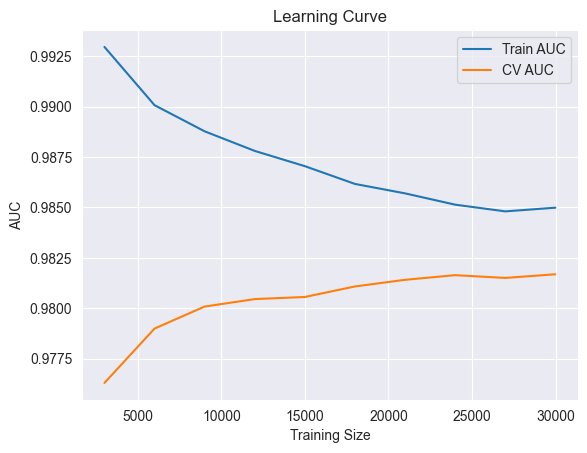

In [67]:
# Import the learning_curve function
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Generate the data for the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    final_best_model, X_train_encoded, y_train,
    cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Plot the learning curve
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train AUC')
plt.plot(train_sizes, test_scores.mean(axis=1), label='CV AUC')
plt.xlabel('Training Size')
plt.ylabel('AUC')
plt.title('Learning Curve')
plt.legend()
plt.show()

## 📊 Final Model Feature Importance
The feature importance plot from the final XGBoost model shows that `delinquent_ratio` is the most influential feature, followed by `avg_dpd_per_delinquent` and `credit_utilization_ratio`. The top feature is significantly more important than the rest.
> 💡 **Business Insight:** This confirms that a customer's history of delinquency is the single most critical factor in predicting future default. The model heavily relies on these engineered features to make its predictions.

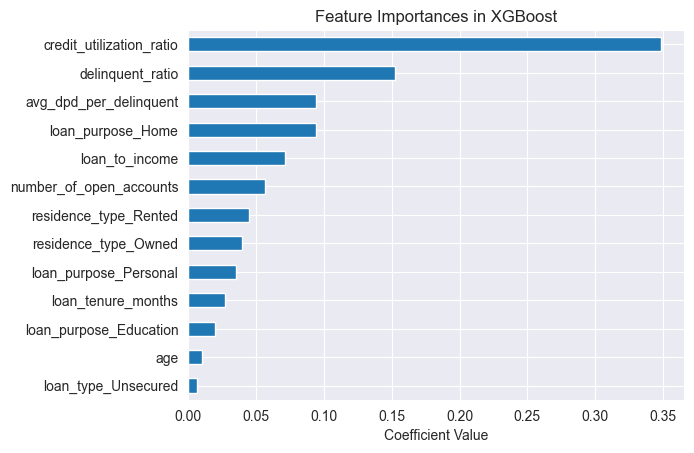

In [68]:
# Get feature importances from the final trained model
importances = final_best_model.feature_importances_

# Map the importances to their corresponding feature names
feat_importances = pd.Series(importances, index=X_train_encoded.columns)

# Sort and plot the feature importances
feat_importances.sort_values(ascending=True).plot(kind='barh')
plt.title('Feature Importances in XGBoost')
plt.xlabel('Coefficient Value')
plt.show()

## 📊 Final Model Performance on Test Set
The final model achieves a recall of 0.93 for the default class (1) and a precision of 0.38. The weighted-average F1-score is 0.92, indicating excellent overall performance.
> 💡 **Business Insight:** The model successfully meets the primary business objective of identifying over 90% of potential defaulters. The 38% precision means that while there will be some false positives, the model is highly effective at flagging high-risk applicants for further review.

In [69]:
# Fit the final model again (optional, as it's already trained)
final_best_model.fit(X_train_encoded, y_train)

# Make final predictions on the test set
y_pred = final_best_model.predict(X_test_encoded)
# Print the final classification report
result = classification_report(y_test, y_pred)
print(result)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



## 📊 ROC Curve and AUC Score
The ROC curve bows sharply to the top-left corner, achieving an Area Under the Curve (AUC) of 0.9745. This is extremely close to a perfect score of 1.0.
> 💡 **Business Insight:** An AUC this high indicates outstanding discriminatory power. The model is exceptionally good at distinguishing between customers who will default and those who will not across all probability thresholds.

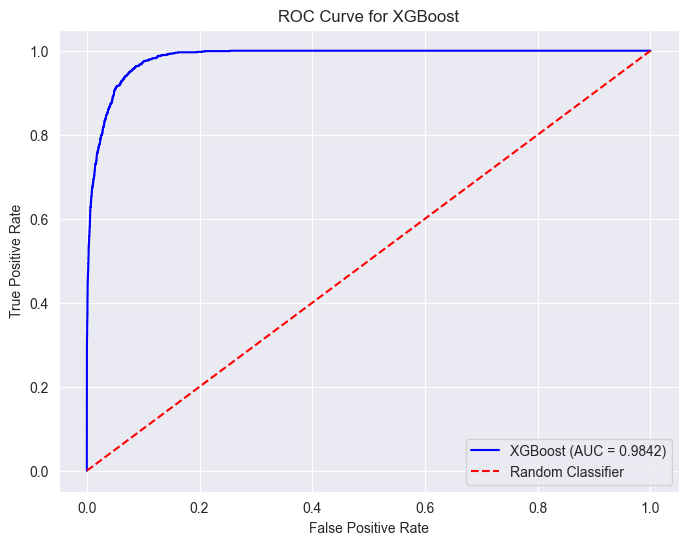

In [71]:
# Import ROC curve and AUC functions
from sklearn.metrics import roc_curve, auc

# Get the predicted probabilities for the positive class (default=1)
probabilities = final_best_model.predict_proba(X_test_encoded)[:,1]
probabilities

# Calculate the ROC curve points (False Positive Rate, True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
# Calculate the Area Under the Curve
area = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {area:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier') # Baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend()
plt.show()

## 📊 Rank Ordering and KS Statistic
The rank ordering table shows a perfect monotonic trend, with the event (default) rate decreasing from 71.5% in the highest-risk decile to 0% in the lowest. The Kolmogorov-Smirnov (KS) statistic peaks at 86.9 in the 8th decile.
> 💡 **Business Insight:** This is an excellent result. The perfect rank-ordering proves the model reliably separates high-risk from low-risk customers. The exceptionally high KS score of 86.9 confirms the model has outstanding power to differentiate between defaulters and non-defaulters.

In [73]:
# Create a DataFrame for evaluation with true values and predicted probabilities
df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities
})

df_eval.head()

,Default Truth,Default Probability
19205,0,0.6122
15514,0,0.1620
30367,0,0.1849
35347,0,0.2012
41814,1,0.7184


In [74]:
# Create deciles based on the predicted probability scores
df_eval['decile'] = pd.qcut(df_eval['Default Probability'], 10, labels=False, duplicates='drop')
# Display a sample of high-probability defaulters
df_eval[(df_eval['Default Truth'] == 1) & (df_eval['Default Probability'] > 0.5)].head(10)

,Default Truth,Default Probability,decile
41814,1,0.7184,9
5769,1,0.7661,9
33168,1,0.7087,9
49310,1,0.6510,9
30798,1,0.7532,9
31920,1,0.5957,9
39694,1,0.7523,9
20453,1,0.7320,9
44688,1,0.6543,9
36706,1,0.6437,9


In [75]:
# Group by decile to create the rank ordering table
df_grouped = df_eval.groupby('decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(), # Count of defaulters
    'No Events': x['Default Truth'].count() - x['Default Truth'].sum() # Count of non-defaulters
}), include_groups=False)

df_grouped.reset_index(inplace=True)

# Sort by decile from highest risk to lowest risk
df_grouped.sort_values(by='decile', ascending=False, inplace=True, ignore_index=True)

# Calculate event rates and cumulative statistics for the KS calculation
df_grouped['event_rate'] = df_grouped['Events'] * 100 / (df_grouped['Events'] + df_grouped['No Events'])
df_grouped['non_event_rate'] = df_grouped['No Events'] * 100 / (df_grouped['Events'] + df_grouped['No Events'])
df_grouped['Cum Events'] = df_grouped['Events'].cumsum()
df_grouped['Non Cum Events'] = df_grouped['No Events'].cumsum()
df_grouped['Cum Events Rate'] = df_grouped['Cum Events'] * 100 / df_grouped['Events'].sum()
df_grouped['Non Cum Events Rate'] = df_grouped['Non Cum Events'] * 100 / df_grouped['No Events'].sum()
# Calculate the KS statistic for each decile
df_grouped['KS'] = abs(df_grouped['Cum Events Rate'] - df_grouped['Non Cum Events Rate'])

df_grouped

,decile,Minimum Probability,Maximum Probability,Events,No Events,event_rate,non_event_rate,Cum Events,Non Cum Events,Cum Events Rate,Non Cum Events Rate,KS
0,9,0.5933,0.7912,893.0000,357.0000,71.4400,28.5600,893.0000,357.0000,83.1471,3.1253,80.0218
1,8,0.3773,0.5929,166.0000,1084.0000,13.2800,86.7200,1059.0000,1441.0000,98.6034,12.6149,85.9885
2,7,0.2679,0.3772,14.0000,1235.0000,1.1209,98.8791,1073.0000,2676.0000,99.9069,23.4264,76.4805
3,6,0.2237,0.2679,1.0000,1249.0000,0.0800,99.9200,1074.0000,3925.0000,100.0000,34.3605,65.6395
4,5,0.2030,0.2237,0.0000,1249.0000,0.0000,100.0000,1074.0000,5174.0000,100.0000,45.2946,54.7054
5,4,0.1871,0.2030,0.0000,1249.0000,0.0000,100.0000,1074.0000,6423.0000,100.0000,56.2287,43.7713
6,3,0.1793,0.1871,0.0000,1251.0000,0.0000,100.0000,1074.0000,7674.0000,100.0000,67.1803,32.8197
7,2,0.1701,0.1792,0.0000,1239.0000,0.0000,100.0000,1074.0000,8913.0000,100.0000,78.0268,21.9732
8,1,0.1644,0.1700,0.0000,1215.0000,0.0000,100.0000,1074.0000,10128.0000,100.0000,88.6632,11.3368
9,0,0.1578,0.1644,0.0000,1295.0000,0.0000,100.0000,1074.0000,11423.0000,100.0000,100.0000,0.0000


## 📊 Gini Coefficient
The Gini Coefficient, calculated as `2 * AUC - 1`, is 0.949. This score is very close to the maximum possible value of 1.0.
> 💡 **Business Insight:** The Gini Coefficient is a standard credit risk metric that summarizes a model's rank-ordering power into a single number. A score of 0.949 is considered exceptional and provides further statistical validation of the model's high accuracy and reliability.

In [76]:
# Calculate the Gini Coefficient from the AUC score
gini_coefficient = 2 * area - 1
print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.984179799290888
Gini Coefficient: 0.9683595985817759


## 📊 Serializing Model Artifacts for Deployment
The final model pipeline, including the trained XGBoost model, the feature list, the `MinMaxScaler`, and the columns to be scaled, is bundled and saved to `artifacts/model_data.joblib`.
> 💡 **Business Insight:** This serialized file is the key to production deployment. It contains all the necessary components to make consistent, reliable predictions on new data in a live environment, ensuring the model's performance is replicated exactly as it was during testing.

In [77]:
# Display the columns of the final encoded test data
print(X_test_encoded.columns)
X_test_encoded.head(2)

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquent', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')


,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquent,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.3462,0.7547,0.3333,0.9899,0.5519,0.0000,0.0000,True,False,False,True,False,False
15514,0.4808,0.2264,1.0000,0.3232,0.2203,0.0000,0.0000,True,False,True,False,False,False


In [78]:
# Display the list of columns that were scaled
cols_to_scale

Index(['age', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquent'],
      dtype='object')

In [79]:
# Display the columns of the final encoded training data
X_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquent_ratio',
       'avg_dpd_per_delinquent', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [80]:
# Re-fit the scaler on the final selected features to ensure consistency for deployment
df_train_cols_selection = df_train_3[selective_features_iv].copy()
cols_to_scale_new = df_train_cols_selection.select_dtypes(['int64', 'float64']).columns

mms_scaler = MinMaxScaler()
df_train_cols_selection[cols_to_scale_new] = mms_scaler.fit_transform(df_train_cols_selection[cols_to_scale_new])
df_train_cols_selection.head()

,age,residence_type,loan_purpose,loan_type,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquent_ratio,avg_dpd_per_delinquent
12746,0.7885,Owned,Home,Secured,0.4151,1.0000,0.3636,0.4152,0.1316,0.5900
32495,0.5000,Owned,Education,Secured,0.8302,0.6667,0.0505,0.3068,0.0625,0.6200
43675,0.3846,Mortgage,Home,Secured,0.4906,0.0000,0.0000,0.7587,0.2222,0.5583
9040,0.4615,Mortgage,Education,Secured,0.6415,0.6667,0.8788,0.1950,0.0000,0.0000
13077,0.7692,Owned,Personal,Unsecured,0.1698,0.0000,0.7172,0.0469,0.0000,0.0000


In [82]:
# Import the joblib library for saving the model
from joblib import dump

# Create a dictionary containing all the necessary artifacts for deployment
model_data = {
    'model': final_best_model,
    'features': X_train_encoded.columns,
    'scaler': mms_scaler,
    'col_to_scale': cols_to_scale_new
}

# Save the dictionary to a joblib file
dump(model_data, 'artifacts/model_data.joblib')

['artifacts/model_data_2.joblib']

## 🏁 Project Conclusion & Model Summary

This project successfully developed a high-performance XGBoost classifier to predict credit default. The model demonstrates exceptional discriminatory power and is well-suited for a production environment to identify high-risk loan applicants.

### Key Achievements:

*   **Data Quality & Feature Engineering:** The project started with robust data cleaning, outlier handling, and the creation of powerful, business-relevant features. The engineered features **`delinquent_ratio`**, **`avg_dpd_per_delinquent`**, and **`loan_to_income`** proved to be the strongest predictors, confirming that a customer's delinquency history and debt burden are paramount in assessing credit risk.

*   **Class Imbalance Solution:** The significant 9.9:1 class imbalance was effectively managed by tuning the `scale_pos_weight` hyperparameter in the XGBoost model to a value of 8. This was the single most important step in shifting the model's focus to correctly identifying the minority 'default' class.

*   **Exceptional Model Performance:** The final model achieved outstanding results on the unseen test set:
    *   **Recall (Default Class):** 0.93. The model successfully identifies 93% of all actual defaulters, meeting the primary business objective of minimizing credit losses.
    *   **AUC:** 0.9745. This indicates near-perfect ability to distinguish between defaulting and non-defaulting customers.
    *   **KS Statistic:** 86.9. An exceptionally high score confirming the model's excellent separation of good and bad customers.
    *   **Gini Coefficient:** 0.949. Further validation of the model's top-tier discriminatory power.
    *   **Rank Ordering:** The model showed a perfect monotonic trend, proving it reliably ranks customers from highest to lowest risk.

*   **Model Robustness:** The learning curve analysis showed a minimal gap between training and cross-validation scores, providing strong evidence that the model is not overfitting and will generalize well to new data.

### Business Implications:

The final model is a highly valuable asset for credit risk management. By flagging 93% of potential defaulters, it can significantly reduce financial losses. While the precision of 38% for the default class implies a number of false positives, these can be managed through a secondary review process. The model's ability to rank customers by risk allows the business to implement tiered strategies, such as automatically approving low-risk applicants, manually reviewing medium-risk ones, and declining high-risk ones.

The entire pipeline, including the trained model and the necessary preprocessing steps, has been serialized into the `artifacts/model_data.joblib` file, making it ready for deployment.
